In [1]:

import jax, os
print("jax", jax.__version__)
print("jaxlib", jax.lib.__version__)
print("JAX_PLATFORMS =", os.environ.get("JAX_PLATFORMS"))
print("LD_LIBRARY_PATH =", os.environ.get("LD_LIBRARY_PATH"))
print(jax.devices())


jax 0.6.2
jaxlib 0.6.2
JAX_PLATFORMS = None
LD_LIBRARY_PATH = None
[CudaDevice(id=0)]


In [2]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

#jax.config.update("jax_enable_x64", True)

import optax
import flax.linen as nn
from flax.training.train_state import TrainState
 
import matplotlib.pyplot as plt

import sys
import json
from pathlib import Path
from toolbox import *

In [3]:
seed = 1234
key = jax.random.key(seed)
# # Forces JAX to use the asynchronous CUDA allocator, heavily reducing fragmentation
# import os
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "cuda_async"

# Load json

In [4]:
def _strip_comment_keys(obj):
    """Recursively drop any keys that start with '//'."""
    if isinstance(obj, dict):
        return {k: _strip_comment_keys(v) for k, v in obj.items()
                if not (isinstance(k, str) and k.startswith("//"))}
    if isinstance(obj, list):
        return [_strip_comment_keys(x) for x in obj]
    return obj

def load_config_dict(config_directory: Path, filename: str = "configuration.json") -> dict:
    path = (config_directory / filename).resolve()
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return _strip_comment_keys(data)

config_directory = Path("")
cfg = load_config_dict(config_directory, "configuration.json")

print("chi =", -cfg["chi_kHz"], "kHz")
print("qubit anharmonicity =", cfg["anharmonicity_MHz"], "MHz")

# Hamiltonian parameters (MHz units)
chi = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
qubit_anham = 2 * jnp.pi * cfg["anharmonicity_MHz"]
cavity_self_kerr = 2*jnp.pi*cfg["self_Kerr_kHz"]*1e-3  # cavity self-Kerr MHz


# Relaxation times (not used in this unitary optimizer, but keep)
t1_qub = cfg["qubit_T1_us"]
t2_qub = cfg["qubit_T2_us"]
t1_cav = cfg["storage_T1_us"]

chi = -660.8313 kHz
qubit anharmonicity = -164.271 MHz


## Problem parameters

#### Static constants

In [5]:
mu_qub = 20.0 #make the coeff big enough so that the amps remain betwee -2 and 2
mu_cav = 20.0

In [6]:
k = 2 #quartic bsplines (only 3 non zero bsplines simultaneously)
bspln_num = 20    # Desired number of basis pulses

# Skip exactly 'k' on both sides to use purely uniform interior splines
skip_left = k
skip_right = k
n = bspln_num + skip_left + skip_right  # Total knots required = 24


# Grid interval (delta) must be a multiple of 4ns. 
delta_ns = 64
m = n - k  # Total uniform intervals = 22

T_ns_hw = m * delta_ns
T_us_hw = T_ns_hw / 1000.0

time_start = 0.0
time_end = T_us_hw

# A degree k B-spline spans exactly k+1 intervals
L_ns = (k + 1) * delta_ns  


print("--- Pulse Properties ---")
print(f"B-spline Degree (k)     : {k}")
print(f"Grid step (delta_ns)    : {delta_ns} ns")
print(f"Single pulse length     : {L_ns} ns")
print(f"Total sequence duration : {T_ns_hw} ns ({T_us_hw} us)")
print(f"Max overlapping pulses  : {k + 1}")
print("------------------------")
assert L_ns % 4 == 0, "Pulse length is not a multiple of 4 ns!"

--- Pulse Properties ---
B-spline Degree (k)     : 2
Grid step (delta_ns)    : 64 ns
Single pulse length     : 192 ns
Total sequence duration : 1408 ns (1.408 us)
Max overlapping pulses  : 3
------------------------


In [7]:
t_drive = T_us_hw
ndt_drive = 200

num_bspln = bspln_num 
num_bspln

20

In [8]:
inp_shape = (1,)
osz = num_bspln * 4
rec_features = osz
dense_features = [int(osz * 2), int(osz * 3), int(osz * 2)]
learning_rate=0.00015

rec_features, dense_features

(80, [160, 240, 160])

#### Dynamic const

In [9]:
N_cav = 25

t_idle = 15 #in us on average

# Measured deterministic phase-space rotation caused by one qubit readout.
# Convention: phi < 0 means the Wigner function rotates clockwise by |phi|.
readout_wigner_rotation_deg = -18.6807
readout_wigner_rotation_rad = jnp.deg2rad(readout_wigner_rotation_deg)


In [31]:
save_name = "trained_nn15_readout_rotation_20bs_cat_target"

In [11]:
# psi_target_cav = basis(N_cav, 2)
psi_target_cav = coherent(N_cav,2.0)-coherent(N_cav,-2.0)

psi_target_cav /= jnp.sqrt(hconj(psi_target_cav) @ psi_target_cav)

## Driven Hamiltonian

In [12]:
def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a
    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    H_disp = (chi / 2) * n_phot @ (one - sigz)

    # Combined drift Hamiltonian
    H_drift = H_disp 
    
    ht = [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],                
        [mu_cav * adag, jnp.conj(e_cav), 1, 1] 
    ]
    return ht

def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    hmat = hmat_from_htree(htree)
    return evol_hdt_exp(hmat, dt)

def make_drive(N_cav, chi):
    
    def drive(rho_init, es_qub, es_cav, dts):
        
        def f(rho, x):
            e_qub, e_cav, dt = x
            uevol = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            return uevol @ rho @ hconj(uevol), None
    
        rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])
        return rho_fin
    
    return drive

## Time-grids and B-splines

In [13]:
t_drive_edges = jnp.linspace(0, t_drive, ndt_drive + 1)
t_drive_mids = (t_drive_edges[1:] + t_drive_edges[:-1]) / 2
t_drive_intvs = t_drive_edges[1:] - t_drive_edges[:-1]

In [14]:
bspline_builder = setup_bspline_builder(0, t_drive_edges[-1], n, k, skip_left, skip_right)

bsplns_mids = bspline_builder(t_drive_mids)
bsplns_edges = bspline_builder(t_drive_edges)

knots = bknots_on_interval(0, t_drive_edges[-1], n, k)
knots = np.unique(knots)

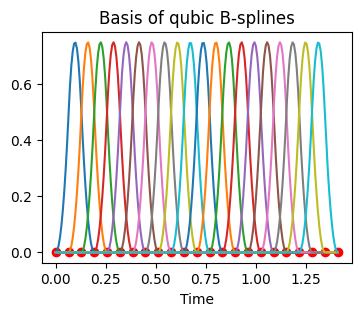

In [15]:
# TEST
fig, ax = plt.subplots(figsize=(4, 3))

for i in range(bsplns_edges.shape[0]):
    ax.plot(t_drive_edges, bsplns_edges[i])
        
ax.scatter(knots, np.zeros_like(knots), color="red");   
ax.set_xlabel("Time");
ax.set_title("Basis of qubic B-splines");
# TEST

In [16]:
def ctrl_from_coeffs(ctrl_coeffs, bsplns):
    ctrls_real = ctrl_coeffs @ bsplns
    e_qub = ctrls_real[0, ...] + 1j * ctrls_real[1, ...]
    e_cav = ctrls_real[2, ...] + 1j * ctrls_real[3, ...]
    return e_qub, e_cav

## Relaxation

In [17]:
def qubit_ops():
    g = basis(2)       # |g> = index 0
    e = basis(2, 1)    # |e> = index 1

    Pg = g @ hconj(g)
    Pe = e @ hconj(e)

    sm = g @ hconj(e)  # |g><e|, relaxation operator
    sp = e @ hconj(g)  # |e><g|, excitation operator

    sz = Pg - Pe       # diag(+1, -1)

    return g, e, Pg, Pe, sm, sp, sz

def liouv_relax_channel(c):
    l = tensor(c, c.conj())
    l -= 1 / 2 * tensor(hconj(c) @ c, identity(len(c)))
    l -= 1 / 2 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return l

def eval_idling_matrix(cs, t):
    l = sum(liouv_relax_channel(c) for c in cs)
    return jsp.linalg.expm(l * t)

def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    get_t_phi_qub = lambda t1, t2: 1 / ((1 / t2) - (1 / t1) / 2)
    t_phi_qub = get_t_phi_qub(t1_qub, t2_qub)

    g, e, Pg, Pe, sm, sp, sz = qubit_ops()

    sig_down = tensor(sm, identity(N_cav))
    sigz = tensor(sz, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))
    
    c_ops = [
        1 / jnp.sqrt(t1_qub) * sig_down,
        1 / jnp.sqrt(t_phi_qub) * sigz / jnp.sqrt(2),
        1 / jnp.sqrt(t1_cav) * a,
    ]

    return c_ops

def make_idle(N_cav, t1_qub, t2_qub, t1_cav, t):
    cs = build_c_ops(N_cav, t1_qub, t2_qub, t1_cav)
    idling_matrix = eval_idling_matrix(cs, t)

    def idle(rho):
        rho_liouv = rho.reshape(-1, 1)
        rho_liouv = idling_matrix @ rho_liouv
        return rho_liouv.reshape(rho.shape)

    return idle


def make_cavity_phase_rotation(N_cav, phase_space_angle_rad):
    """
    Apply a deterministic phase-space rotation to the cavity.

    Convention:
        U = exp(i * phi * a^dag a)

    Therefore:
        |alpha> -> |alpha * exp(i * phi)>

    So phi = -19 deg means the Wigner function rotates by -19 deg.
    """

    n = jnp.arange(N_cav)
    U_cav = jnp.diag(jnp.exp(1j * phase_space_angle_rad * n))

    U = tensor(identity(2), U_cav)
    Udag = hconj(U)

    def rotate(rho):
        return U @ rho @ Udag

    return rotate


## Measurement with qubit reset

In [18]:
# def measure_sz(key, rho_init): 
 
#     probs = rho_init.diagonal().reshape(2, -1).sum(axis=1).real #[p_ground, p_excited]
#     outcome_indx = jax.random.choice(key, 2, p=probs) #indx=0->ground   indx=1->excited
#     prob = probs[outcome_indx] #gives the probability of the measured outcome
    
#     idx_mid = rho_init.shape[-1] // 2 #=N_cav,  rho_init has shape (2 * N_cav, 2 * N_cav)

#     #if outcome_indx == 0: rho_fin_cav = rho_gg,  else  rho_fin_cav = rho_ee
#     rho_fin_cav = jnp.where(outcome_indx == 0, rho_init[:idx_mid, :idx_mid], rho_init[idx_mid:, idx_mid:]) 
    
#     # Qubit reset to ground
#     rho_fin_qub = basis(2) @ hconj(basis(2))
    
#     rho_fin = tensor(rho_fin_qub, rho_fin_cav)
#     rho_fin /= jnp.trace(rho_fin)
    
#     # Outcome definition
#     outcome = 1 - 2 * outcome_indx 
#     # for qubit in ground state we get outcome = +1, for qubit in excited state we get outcome = -1
#     return outcome, prob, rho_fin


def measure_sz(key, rho_init, chi=chi, t_feedback=0.42,readout_duration=1.6): 

    # chi should be in rad / us
    # t_reset_delay is in us, here 0.600 us = 600 ns
    t_reset_delay =t_feedback+readout_duration
    
    probs = rho_init.diagonal().reshape(2, -1).sum(axis=1).real  # [p_ground, p_excited]
    outcome_indx = jax.random.choice(key, 2, p=probs)  # indx=0->ground   indx=1->excited
    prob = probs[outcome_indx]  # gives the probability of the measured outcome
    
    idx_mid = rho_init.shape[-1] // 2  # =N_cav,  rho_init has shape (2 * N_cav, 2 * N_cav)

    # if outcome_indx == 0: rho_fin_cav = rho_gg,  else  rho_fin_cav = rho_ee
    rho_fin_cav = jnp.where(
        outcome_indx == 0,
        rho_init[:idx_mid, :idx_mid],
        rho_init[idx_mid:, idx_mid:],
    )

    # If the qubit was measured excited, it stays excited during the finite delay
    # before the conditional reset pi-pulse is actually applied.
    # During this delay, the cavity evolves with H = chi * n_phot.
    # Therefore rho_cav -> exp(-i chi n t) rho_cav exp(+i chi n t).
    n = jnp.arange(idx_mid)  # photon numbers [0, 1, ..., N_cav-1]

    phase_e = jnp.exp(-1j * chi * n * t_reset_delay)
    # phase_e[n] = exp(-i * chi * n * t_reset_delay)

    rho_fin_cav_delayed = (
        phase_e[:, None]
        * rho_fin_cav
        * jnp.conj(phase_e[None, :])
    )
    # equivalent to U_e @ rho_fin_cav @ U_e^\dagger,
    # with U_e = exp(-i * chi * n_phot * t_reset_delay)

    # if outcome_indx == 1, the qubit was measured excited,
    # so we apply the excited-state dispersive delay.
    # if outcome_indx == 0, the qubit was measured ground,
    # so the cavity state is left unchanged.
    rho_fin_cav = jnp.where(
        outcome_indx == 1,
        rho_fin_cav_delayed,
        rho_fin_cav,
    )
    
    # Qubit reset to ground
    rho_fin_qub = basis(2) @ hconj(basis(2))
    
    rho_fin = tensor(rho_fin_qub, rho_fin_cav)
    rho_fin /= jnp.trace(rho_fin)
    
    # Outcome definition
    outcome = 1 - 2 * outcome_indx 
    # for qubit in ground state we get outcome = +1, for qubit in excited state we get outcome = -1
    
    return outcome, prob, rho_fin


## Fidelity of the cavity state

In [19]:
def make_fidelity_cav(psi_target_cav):

    def fidelity_cav(rho):
        idx_mid = rho.shape[-1] // 2
        rho_cav = rho[:idx_mid, :idx_mid] + rho[idx_mid:, idx_mid:]
        return (hconj(psi_target_cav) @ rho_cav @ psi_target_cav)[0][0].real

    return fidelity_cav

## RNN

In [20]:
def init_carry(key, rec_features, inp_shape):
    gru_cell = nn.GRUCell(features=rec_features)
    return gru_cell.initialize_carry(key, inp_shape)

def create_flax_state(key,
                      rec_features, dense_features,
                      inp_shape, learning_rate,
                      *, print_summary):
    
    class Model(nn.Module):
    
        @nn.compact
        def __call__(self, carry, x):
            
            gru_cell = nn.GRUCell(features=rec_features)
            carry, x = gru_cell(carry, x)
            
            for ndf in dense_features:
                x = nn.Dense(ndf)(x)
                x = jax.nn.relu(x)
                
            out_layer = nn.Dense(4 * num_bspln)
            x = out_layer(x)
            x = x.reshape(4, num_bspln)
            
            return carry, x

    model = Model()

    fake_key = jax.random.key(0)
    fake_carry = init_carry(fake_key, rec_features, inp_shape)
    fake_inp = jnp.ones(inp_shape)
    params = model.init(key, fake_carry, fake_inp)["params"]

    # optimizer = optax.adam(learning_rate=learning_rate)
    optimizer = optax.chain( #avoid unlikely trajectory to create catastrophic update
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=learning_rate),
    )

    flax_state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    if print_summary:
        print(model.tabulate(fake_key, fake_carry, fake_inp))

    return flax_state

def apply_nn(flax_state, params, carry, inp):
    return flax_state.apply_fn({'params': params}, carry, inp)



In [21]:
key, subkey = jax.random.split(key)
flax_state = create_flax_state(
    subkey, rec_features, dense_features, inp_shape, learning_rate,
    print_summary=True
)


                                 Model Summary                                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module  ┃ inputs        ┃ outputs         ┃ params            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│              │ Model   │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[4,20] │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0    │ GRUCell │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[80]   │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0/ir │ Dense   │ float32[1]    │ float32[80]     │ bias: float32[80] │
│              │         │               │                 │ kernel:           │
│              │         │ 

## Time step  
- 1) Measurement
- 2) Fidelity
- 3) Idling (decay)
- 3) RNN interrogation
- 3) Qubit reset

In [22]:
def make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    fidelity_cav = make_fidelity_cav(psi_target_cav)
    idle = make_idle(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
    drive = make_drive(N_cav, chi)

    # Deterministic readout-induced cavity phase kick.
    readout_rotate = make_cavity_phase_rotation(
        N_cav,
        readout_wigner_rotation_rad,
    )
    
    def time_step(key, rho, flax_state, params, carry):
        meas_out, prob, rho = measure_sz(key, rho)
        
        rho = readout_rotate(rho) #Deterministic cavity rotation caused by the readout pulse.

        rho = idle(rho)
        rnn_inp = jnp.array([meas_out], dtype=float)
        carry, ctrl_coeffs = apply_nn(flax_state, params, carry, rnn_inp)
        es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
        rho = drive(rho, es_qub, es_cav, t_drive_intvs)  
        fid = fidelity_cav(rho)
        return rho, carry, fid, meas_out, prob
    
    return time_step

## Trajectory

In [23]:
def make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    time_step = make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory(key, flax_state, params, num_time_steps):
        
        def f(scan_carry, _):
            key, rho, carry = scan_carry
            key, subkey = jax.random.split(key)
            rho, carry, fid, meas_out, prob = time_step(subkey, rho, flax_state, params, carry)
            y = fid, meas_out, prob
            scan_carry = key, rho, carry
            return scan_carry, y
        
        key1, key2 = jax.random.split(key)
        carry = init_carry(key1, rec_features, inp_shape)
        psi_init = tensor(basis(2), psi_target_cav)
        scan_carry = key2, psi_init @ hconj(psi_init), carry
        _, ys = jax.lax.scan(f, scan_carry, length=num_time_steps)
        return ys
    
    return trajectory

## Trajectory with reward gradients

In [24]:
def make_trajectory_with_rewgrad(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    
    trajectory = make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory_with_rewgrad(key, flax_state, num_time_steps):
    
        def func(params):
            traj_out = trajectory(key, flax_state, params, num_time_steps)
            fid, meas_out, prob = traj_out
            # rew = -jnp.log(1 - fid.mean())
            # log_prob = jnp.log(prob).sum()
            # return rew + jax.lax.stop_gradient(rew) * log_prob, traj_out
    
            eps = 1e-8

            fid_mean = jnp.real(fid.mean())
            fid_mean = jnp.clip(fid_mean, 0.0, 1.0 - eps)

            rew = -jnp.log(1.0 - fid_mean)

            prob_safe = jnp.clip(prob, eps, 1.0)
            log_prob = jnp.log(prob_safe).sum()

            return rew + jax.lax.stop_gradient(rew) * log_prob, traj_out


        grad_func = jax.grad(func, has_aux=True)
        rewgrad, traj_out = grad_func(flax_state.params)
        return rewgrad, traj_out
    
    return trajectory_with_rewgrad

## Train on batch

In [25]:
def make_train_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory_with_rewgrad = make_trajectory_with_rewgrad(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_with_rewgrad_vec = jax.vmap(
            trajectory_with_rewgrad, in_axes=(0, None, None)
        )
    
    @jax.jit
    def train_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        rewgrad, traj_out = trajectory_with_rewgrad_vec(keys, flax_state, num_time_steps)
        lossgrad = jax.tree.map(lambda x: -x.mean(axis=0), rewgrad)
        flax_state = flax_state.apply_gradients(grads=lossgrad) 
        return flax_state, traj_out
    
    return train_on_batch

## Test on batch

In [26]:
def make_test_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory = make_trajectory(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_vec = jax.vmap(
            trajectory, in_axes=(0, None, None, None)
        )
    
    @jax.jit
    def test_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        traj_out = trajectory_vec(keys, flax_state, flax_state.params, num_time_steps)
        return traj_out
    
    return test_on_batch

## >>> Run

In [27]:
mean_fids_train = []

In [28]:
num_time_steps_train = 16
num_time_steps_test = 150
batch_size = 32

In [29]:
train_on_batch = make_train_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_train)

test_on_batch = make_test_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_test)

In [36]:
init_lr = 0.000050
final_lr = 0.000001

constant_steps = 1500
decay_steps = 1500
total_steps = constant_steps + decay_steps

lr_schedule = optax.join_schedules(
    schedules=[
        optax.constant_schedule(init_lr),
        optax.linear_schedule(
            init_value=init_lr,
            end_value=final_lr,
            transition_steps=decay_steps,
        ),
        optax.constant_schedule(final_lr),
    ],
    boundaries=[
        constant_steps,
        constant_steps + decay_steps,
    ],
)

my_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=lr_schedule),
)



flax_state = flax_state.replace(
    tx=my_optimizer,
    opt_state=my_optimizer.init(flax_state.params),
)

for i in range(constant_steps + decay_steps):
    key, subkey = jax.random.split(key)
    flax_state, traj_out = train_on_batch(subkey, flax_state)
    fids, meas_outs, probs = traj_out
    mean_fid = fids.mean()
    mean_fids_train.append(mean_fid)

    print("i =",i,"    fid =",mean_fid)

i = 0     fid = 0.7881566
i = 1     fid = 0.7932502
i = 2     fid = 0.8044805
i = 3     fid = 0.7973388
i = 4     fid = 0.78732955
i = 5     fid = 0.79641175
i = 6     fid = 0.78475916
i = 7     fid = 0.7723719
i = 8     fid = 0.801646
i = 9     fid = 0.79601526
i = 10     fid = 0.8049336
i = 11     fid = 0.81001925
i = 12     fid = 0.7972082
i = 13     fid = 0.79649657
i = 14     fid = 0.78898454
i = 15     fid = 0.8023279
i = 16     fid = 0.80280745
i = 17     fid = 0.7844492
i = 18     fid = 0.79405826
i = 19     fid = 0.80144835
i = 20     fid = 0.8067353
i = 21     fid = 0.81215763
i = 22     fid = 0.79936796
i = 23     fid = 0.80526555
i = 24     fid = 0.7979183
i = 25     fid = 0.7994351
i = 26     fid = 0.8005872
i = 27     fid = 0.8070117
i = 28     fid = 0.79236853
i = 29     fid = 0.8121569
i = 30     fid = 0.80577713
i = 31     fid = 0.80276465
i = 32     fid = 0.8024444
i = 33     fid = 0.8023151
i = 34     fid = 0.7984965
i = 35     fid = 0.80303186
i = 36     fid = 0.811

KeyboardInterrupt: 

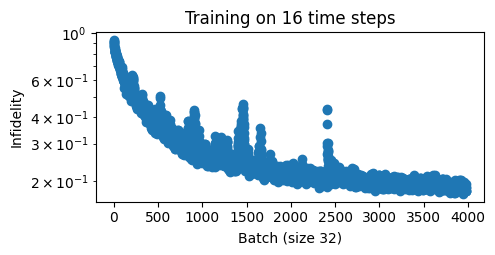

In [37]:
fig, ax = plt.subplots(figsize=(5, 2.2))

ff = jnp.array(mean_fids_train)

ax.scatter(jnp.arange(len(mean_fids_train)), 1 - ff);
ax.set_xlabel(f"Batch (size {batch_size})");
ax.set_ylabel("Infidelity");
ax.set_title(f"Training on {num_time_steps_train} time steps");
ax.set_yscale("log");

#fig.savefig("train.pdf", bbox_inches="tight");

In [38]:

save_flax_state(save_name, flax_state)


In [39]:
#save it in c++ compatible format in the save folder
import struct

def save_cpp_weights(fld, state):
    abs_path = os.path.abspath(fld)
    out_file = os.path.join(abs_path, "weights.bin")

    p = state.params

    arrays = [
        np.asarray(p["GRUCell_0"]["ir"]["kernel"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["ir"]["bias"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["hr"]["kernel"], dtype=np.float32),

        np.asarray(p["GRUCell_0"]["iz"]["kernel"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["iz"]["bias"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["hz"]["kernel"], dtype=np.float32),

        np.asarray(p["GRUCell_0"]["in"]["kernel"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["in"]["bias"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["hn"]["kernel"], dtype=np.float32),

        np.asarray(p["Dense_0"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_0"]["bias"], dtype=np.float32),

        np.asarray(p["Dense_1"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_1"]["bias"], dtype=np.float32),

        np.asarray(p["Dense_2"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_2"]["bias"], dtype=np.float32),

        np.asarray(p["Dense_3"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_3"]["bias"], dtype=np.float32),
    ]

    with open(out_file, "wb") as f:
        f.write(b"GRUCPP01")
        f.write(struct.pack("i", len(arrays)))

        for a in arrays:
            a = np.ascontiguousarray(a)
            f.write(struct.pack("i", a.ndim))
            for s in a.shape:
                f.write(struct.pack("i", s))
            f.write(a.tobytes())

    print(f"Saved C++ weights to {out_file}")


save_cpp_weights(save_name, flax_state)

Saved C++ weights to /home/user/python_experiments/train_feedback_grape/trained_nn15_readout_rotation_20bs_cat_target/weights.bin


# load pretrained RNN

In [ ]:

load_trained = True

if load_trained:
    # === Resume cell 1/2: load an already trained network ===
    #
    # Run the notebook cells above this one first, so that:
    #   - create_flax_state(...) has defined the model architecture,
    #   - flax_state exists as a template TrainState,
    #   - make_train_on_batch(...) is defined.
    #
    # This restores the parameters and optimizer state from an Orbax checkpoint
    # saved by save_flax_state(save_name, flax_state).

    from pathlib import Path
    import orbax.checkpoint as ocp

    resume_save_name = save_name
    resume_step = 1

    def load_flax_state_from_orbax(fld, state_template, *, step=1):
        ckpt_path = Path(fld).resolve() / str(step)
        if not ckpt_path.exists():
            raise FileNotFoundError(f"Checkpoint directory not found: {ckpt_path}")

        ckptr = ocp.Checkpointer(ocp.StandardCheckpointHandler())
        restored_state = ckptr.restore(
            ckpt_path,
            args=ocp.args.StandardRestore(state_template),
        )
        return restored_state

    flax_state = load_flax_state_from_orbax(
        resume_save_name,
        flax_state,
        step=resume_step,
    )

    print(f"Loaded checkpoint from: {Path(resume_save_name).resolve() / str(resume_step)}")
    print("Current TrainState step:", int(flax_state.step))

Loaded checkpoint from: /home/user/python_experiments/train_feedback_grape/trained_nn15_readout_decay_whole_readout_20bs_fock_target/1
Current TrainState step: 3000


Using restored parameters, but reset Adam optimizer state.
resume batch = 0 global step = 3001 fid = 0.9213496446609497
resume batch = 2 global step = 3003 fid = 0.9063553810119629
resume batch = 4 global step = 3005 fid = 0.9263442754745483
resume batch = 6 global step = 3007 fid = 0.912248969078064
resume batch = 8 global step = 3009 fid = 0.8900840878486633
resume batch = 10 global step = 3011 fid = 0.9163939952850342
resume batch = 12 global step = 3013 fid = 0.8960484266281128
resume batch = 14 global step = 3015 fid = 0.9183596968650818
resume batch = 16 global step = 3017 fid = 0.9016588926315308
resume batch = 18 global step = 3019 fid = 0.9168992042541504
resume batch = 20 global step = 3021 fid = 0.8872982263565063
resume batch = 22 global step = 3023 fid = 0.9211763143539429
resume batch = 24 global step = 3025 fid = 0.8998211622238159
resume batch = 26 global step = 3027 fid = 0.9049677848815918
resume batch = 28 global step = 3029 fid = 0.91097092628479
resume batch = 30 g

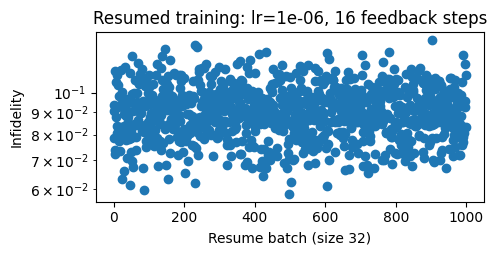

In [ ]:
if load_trained:
    # === Resume cell 2/2: continue optimization from the loaded network ===
    #
    # You can change the learning rate, number of batches, batch size, and number
    # of feedback steps here without rebuilding the whole notebook.

    resume_learning_rate = 0.000004
    resume_num_batches = 1000
    resume_batch_size = 32
    resume_num_feedback_steps_train = 16

    # If False, keep the restored Adam moments and only change the learning rate.
    # This is usually best when continuing the same training run.
    #
    # If True, keep the restored NN weights but reset Adam's internal moments.
    # This can be useful if the resumed optimization behaves strangely.
    resume_reset_optimizer_state = True

    resume_print_every = 2

    # Rebuild the optimizer with the new learning rate.
    # resume_optimizer = optax.adam(learning_rate=resume_learning_rate)
    resume_optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=resume_learning_rate),
    )


    if resume_reset_optimizer_state:
        flax_state = flax_state.replace(
            tx=resume_optimizer,
            opt_state=resume_optimizer.init(flax_state.params),
        )
        print("Using restored parameters, but reset Adam optimizer state.")
    else:
        flax_state = flax_state.replace(tx=resume_optimizer)
        print("Using restored parameters and restored Adam optimizer state.")

    train_on_batch_resume = make_train_on_batch(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        resume_batch_size,
        resume_num_feedback_steps_train,
    )

    mean_fids_resume = []

    for i in range(resume_num_batches):
        key, subkey = jax.random.split(key)
        flax_state, traj_out = train_on_batch_resume(subkey, flax_state)

        fids, meas_outs, probs = traj_out
        mean_fid = fids.mean()
        mean_fids_resume.append(mean_fid)

        if (i % resume_print_every == 0) or (i == resume_num_batches - 1):
            print(
                "resume batch =", i,
                "global step =", int(flax_state.step),
                "fid =", float(mean_fid),
            )

    # Plot only the resumed part.
    fig, ax = plt.subplots(figsize=(5, 2.2))
    ff = jnp.asarray(mean_fids_resume)
    ax.scatter(jnp.arange(len(mean_fids_resume)), 1.0 - ff)
    ax.set_xlabel(f"Resume batch (size {resume_batch_size})")
    ax.set_ylabel("Infidelity")
    ax.set_title(
        f"Resumed training: lr={resume_learning_rate}, "
        f"{resume_num_feedback_steps_train} feedback steps"
    )
    ax.set_yscale("log")
    plt.show()

    # After this cell, run the existing save/export cells below:
    #   save_flax_state(save_name, flax_state)
    #   save_cpp_weights(save_name, flax_state)
    #
    # or set a new save_name before running them, for example:
    #   save_name = "trained_nn15_20bs_start_from_zero_resume_lr3e-6"

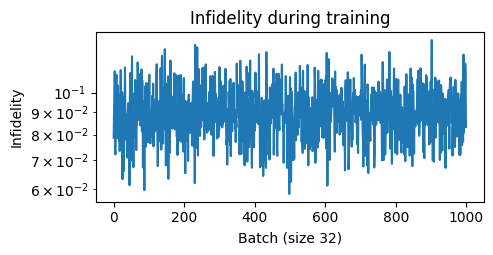

In [ ]:

if load_trained:
    fig, ax = plt.subplots(figsize=(5, 2.2))

    ff = jnp.array(mean_fids_resume)

    ax.semilogy(jnp.arange(len(mean_fids_resume)), 1 - ff);
    ax.set_xlabel(f"Batch (size {batch_size})");
    ax.set_ylabel("Infidelity");
    ax.set_title(f"Infidelity during training");
    ax.set_yscale("log");

#fig.savefig("train.pdf", bbox_inches="tight");

# plot trajectories

In [ ]:
key, subkey = jax.random.split(key)
traj_out = test_on_batch(subkey, flax_state)
fids, meas_outs, probs = traj_out

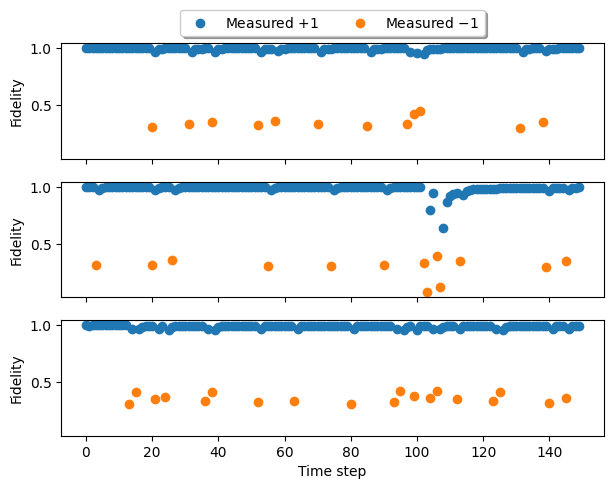

In [ ]:
test_indx = [0, 1, 2]

fig, axes = plt.subplots(len(test_indx), 1, figsize=(7, 1.7 * len(test_indx)), sharex=True, sharey=True)

for ax, ti in zip(axes, test_indx):
    f = fids[ti]
    m = meas_outs[ti]
    arng = jnp.arange(len(f))
    ax.scatter(arng[m==1], f[m==1], label=r"Measured $+1$");
    ax.scatter(arng[m==-1], f[m==-1], label=r"Measured $-1$");
    ax.set_ylabel("Fidelity");
    
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35),
          fancybox=True, shadow=True, ncol=5);
ax.set_xlabel("Time step");
ax.set_title("");

#fig.savefig("stabilize.pdf", bbox_inches="tight");

In [ ]:
idle = make_idle(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
fidelity_cav = make_fidelity_cav(psi_target_cav)

psi_init = tensor(basis(2), psi_target_cav)
rho_init = psi_init @ hconj(psi_init)

In [ ]:
rho = rho_init
fids_nostab = []

for i in range(num_time_steps_test):
    rho = idle(rho)
    f = fidelity_cav(rho)
    fids_nostab.append(f)
    
fids_nostab = jnp.array(fids_nostab)

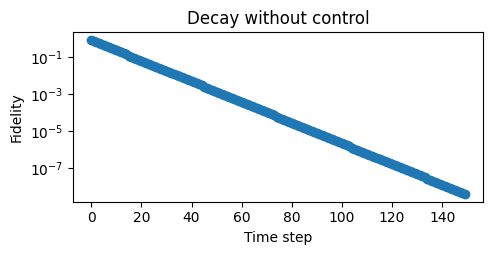

In [ ]:
fig, ax = plt.subplots(figsize=(5.3, 2.2))
ax.scatter(jnp.arange(len(fids_nostab)), fids_nostab);
ax.set_yscale("log");
ax.set_ylabel("Fidelity");
ax.set_xlabel("Time step");
ax.set_title("Decay without control");

#fig.savefig("noctrl.pdf", bbox_inches="tight");

# Normal GRAPE optimization with same Hamiltonian and target state

In [ ]:
from tqdm.auto import tqdm
from datetime import datetime
import os
from pathlib import Path

# Normal GRAPE: prepare |g,0> -> |g> tensor psi_target_cav
# Uses the already-defined feedback-GRAPE Hamiltonian through build_drive_htree.

psi_init_grape = tensor(basis(2), basis(N_cav, 0))       # |g,0>
psi_target_grape = tensor(basis(2), psi_target_cav)      # |g> ⊗ target cavity state

grape_optimizer = optax.adam(learning_rate=2e-3)


def grape_fidelity(psi, psi_target):
    overlap = hconj(psi_target) @ psi
    return jnp.abs(overlap[0, 0]) ** 2


def apply_grape_ctrl(grape_ctrl_coeffs):
    e_qub, e_cav = ctrl_from_coeffs(grape_ctrl_coeffs, bsplns_mids)

    # Uses the exact same drift + control Hamiltonians as feedback-GRAPE.
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)

    psi_t = sesolve_htree(htree, psi_init_grape, t_drive_intvs)
    return psi_t


@jax.jit
def grape_train_step(grape_ctrl_coeffs, grape_opt_state):
    def loss_fn(c):
        psi_t = apply_grape_ctrl(c)
        fid = grape_fidelity(psi_t[-1], psi_target_grape)
        return 1.0 - fid, fid

    (loss_val, fid_val), grads = jax.value_and_grad(loss_fn, has_aux=True)(grape_ctrl_coeffs)
    updates, grape_opt_state = grape_optimizer.update(grads, grape_opt_state)
    grape_ctrl_coeffs = optax.apply_updates(grape_ctrl_coeffs, updates)

    return grape_ctrl_coeffs, grape_opt_state, loss_val, fid_val

100%|██████████| 1000/1000 [00:11<00:00, 84.36it/s, fid=0.997442]


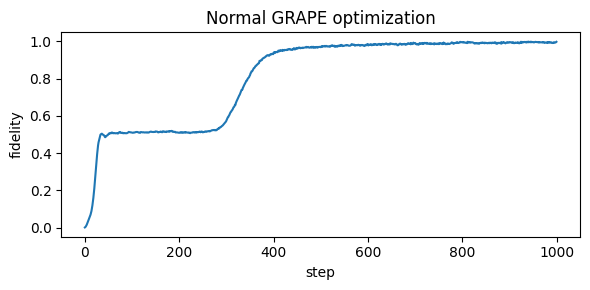

Final normal-GRAPE fidelity: 0.9974423050880432
grape_ctrl_coeffs shape: (4, 20)


In [ ]:
key, subkey = jax.random.split(key)

# Same coefficient shape as the RNN output: [qubit I, qubit Q, cavity I, cavity Q]
grape_ctrl_coeffs = 0.01 * jax.random.normal(subkey, (4, num_bspln))

grape_opt_state = grape_optimizer.init(grape_ctrl_coeffs)

grape_fid_hist = []

n_steps = 1000

pbar = tqdm(range(n_steps))
for i in pbar:
    grape_ctrl_coeffs, grape_opt_state, grape_loss_val, grape_fid_val = grape_train_step(
        grape_ctrl_coeffs, grape_opt_state
    )
    grape_fid_hist.append(float(grape_fid_val))
    pbar.set_postfix(fid=f"{float(grape_fid_val):.6f}")

plt.figure(figsize=(6, 3))
plt.plot(grape_fid_hist)
plt.xlabel("step")
plt.ylabel("fidelity")
plt.title("Normal GRAPE optimization")
plt.tight_layout()
plt.show()

grape_ctrl_coeffs_np = np.asarray(grape_ctrl_coeffs, dtype=float)

print("Final normal-GRAPE fidelity:", grape_fid_hist[-1])
print("grape_ctrl_coeffs shape:", grape_ctrl_coeffs_np.shape)

100%|██████████| 1500/1500 [00:15<00:00, 98.36it/s, fid=1.000067]


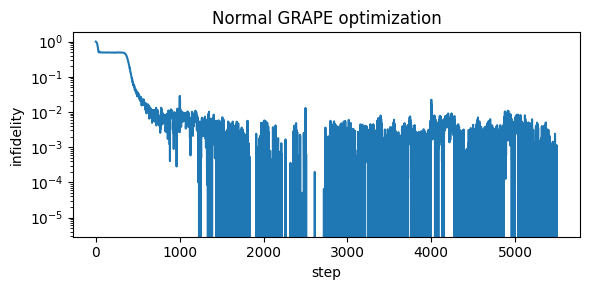

Final normal-GRAPE fidelity: 1.0000665187835693
grape_ctrl_coeffs shape: (4, 20)


In [ ]:
grape_optimizer = optax.adam(learning_rate=1e-7)
grape_opt_state = grape_optimizer.init(grape_ctrl_coeffs)

n_steps = 1500

pbar = tqdm(range(n_steps))
for i in pbar:
    grape_ctrl_coeffs, grape_opt_state, grape_loss_val, grape_fid_val = grape_train_step(
        grape_ctrl_coeffs, grape_opt_state
    )
    grape_fid_hist.append(float(grape_fid_val))
    pbar.set_postfix(fid=f"{float(grape_fid_val):.6f}")

plt.figure(figsize=(6, 3))
plt.semilogy(1 - np.asarray(grape_fid_hist))
plt.xlabel("step")
plt.ylabel("infidelity")
plt.title("Normal GRAPE optimization")
plt.tight_layout()
plt.show()

grape_ctrl_coeffs_np = np.asarray(grape_ctrl_coeffs, dtype=float)

print("Final normal-GRAPE fidelity:", grape_fid_hist[-1])
print("grape_ctrl_coeffs shape:", grape_ctrl_coeffs_np.shape)

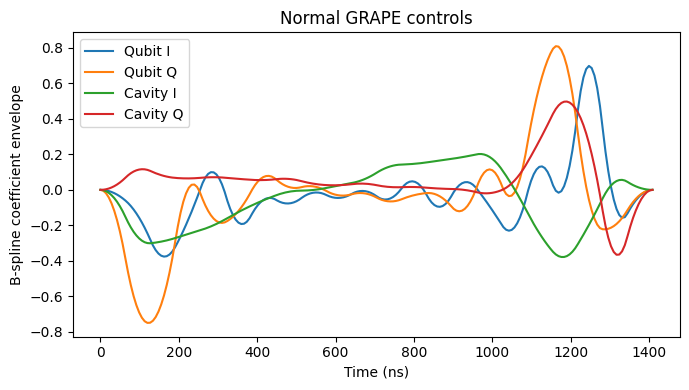

Max raw qubit envelope: 0.8095540747156917
Max raw cavity envelope: 0.49751999219315746
Max physical qubit envelope after mu_qub: 16.191081494313835
Max physical cavity envelope after mu_cav: 9.95039984386315


In [ ]:
grape_fields_edges = grape_ctrl_coeffs_np @ np.asarray(bsplns_edges, dtype=float)

plt.figure(figsize=(7, 4))
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[0], label="Qubit I")
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[1], label="Qubit Q")
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[2], label="Cavity I")
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[3], label="Cavity Q")
plt.xlabel("Time (ns)")
plt.ylabel("B-spline coefficient envelope")
plt.title("Normal GRAPE controls")
plt.legend()
plt.tight_layout()
plt.show()

print("Max raw qubit envelope:", np.max(np.abs(grape_fields_edges[:2])))
print("Max raw cavity envelope:", np.max(np.abs(grape_fields_edges[2:])))
print("Max physical qubit envelope after mu_qub:", mu_qub * np.max(np.abs(grape_fields_edges[:2])))
print("Max physical cavity envelope after mu_cav:", mu_cav * np.max(np.abs(grape_fields_edges[2:])))

In [ ]:
# Build OPX-compatible single B-spline basis sampled at 1 ns

t_ns = np.arange(0, T_ns_hw, 1)
t_us = t_ns / 1000.0

B_1ns = np.asarray(bspline_builder(t_us), dtype=float)
assert B_1ns.shape == (num_bspln, T_ns_hw)

eps = 1e-15
nz0 = np.where(np.abs(B_1ns[0]) > eps)[0]
s0_raw = int(nz0[0]) if len(nz0) else 0

s0_grid = int(np.round(s0_raw / delta_ns) * delta_ns)
s0_grid = (s0_grid // 4) * 4

assert 0 <= s0_grid
assert s0_grid + L_ns <= T_ns_hw

basis_single = B_1ns[0, s0_grid:s0_grid + L_ns].copy()
basis_single[0] = 0.0

max_err = 0.0
for i in range(num_bspln):
    si = s0_grid + i * delta_ns
    seg = B_1ns[i, si:si + L_ns]
    err = np.max(np.abs(seg - basis_single))
    max_err = max(max_err, err)

print("Max shift-match error:", max_err)
assert max_err < 1e-6

# Reconstruct full 1 ns envelopes too
grape_fields_1ns = grape_ctrl_coeffs_np @ B_1ns

# Save next to the feedback-GRAPE RNN weights / weights.bin
# This matches the directory used by save_cpp_weights(save_name, flax_state)
rnn_weights_dir = Path(os.path.abspath(save_name))

if not rnn_weights_dir.exists():
    raise FileNotFoundError(
        f"RNN weights directory does not exist yet: {rnn_weights_dir}\n"
        "Run the feedback-GRAPE save cell first, or check save_name."
    )

out_dir = rnn_weights_dir / "grape_bspline_coeffs"
out_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H_%M")
fid_digits = int(np.floor(float(grape_fid_hist[-1]) * 10_000))
fid_str = f"{fid_digits:04d}"

bundle_filename = (
    f"grape_quad_bspline_bundle_fock_2"
    f"fid_{fid_str}_Tns_{int(T_ns_hw)}_{timestamp}.npz"
)

bundle_path = out_dir / bundle_filename

np.savez(
    bundle_path,
    coeffs=np.asarray(grape_ctrl_coeffs_np, dtype=float),
    coeffs_raw=np.asarray(grape_ctrl_coeffs_np, dtype=float),
    fields_1ns=np.asarray(grape_fields_1ns, dtype=float),
    basis_single=np.asarray(basis_single, dtype=float),
    delta_ns=int(delta_ns),
    L_ns=int(L_ns),
    T_ns=int(T_ns_hw),
    T_us=float(T_us_hw),
    n=int(n),
    k=int(k),
    skip_left=int(skip_left),
    skip_right=int(skip_right),
    num_bspln=int(num_bspln),
    mu_qub=float(mu_qub),
    mu_cav=float(mu_cav),
    chi=float(chi),
    final_fidelity=float(grape_fid_hist[-1]),
)

print("Saved normal-GRAPE B-spline bundle:", bundle_path)

coeffs_cpp_path = out_dir / "grape_init_coeffs_80_f32.bin"

np.asarray(grape_ctrl_coeffs_np.reshape(-1), dtype=np.float32).tofile(coeffs_cpp_path)

print("Saved C++ initial GRAPE coefficients:", coeffs_cpp_path)

Max shift-match error: 1.0295347363520335e-07
Saved normal-GRAPE B-spline bundle: /home/user/python_experiments/train_feedback_grape/trained_nn15_readout_decay_20bs_cat_target/grape_bspline_coeffs/grape_quad_bspline_bundle_fock_2fid_9974_Tns_1408_20260512_18_07.npz
Saved C++ initial GRAPE coefficients: /home/user/python_experiments/train_feedback_grape/trained_nn15_readout_decay_20bs_cat_target/grape_bspline_coeffs/grape_init_coeffs_80_f32.bin


# double check GRAPE pulse with a known working hamiltonian

Loaded optimization bundle from: /home/user/python_experiments/train_feedback_grape/trained_nn15_readout_decay_20bs_cat_target/grape_bspline_coeffs/grape_quad_bspline_bundle_fock_2fid_9974_Tns_1408_20260512_18_07.npz


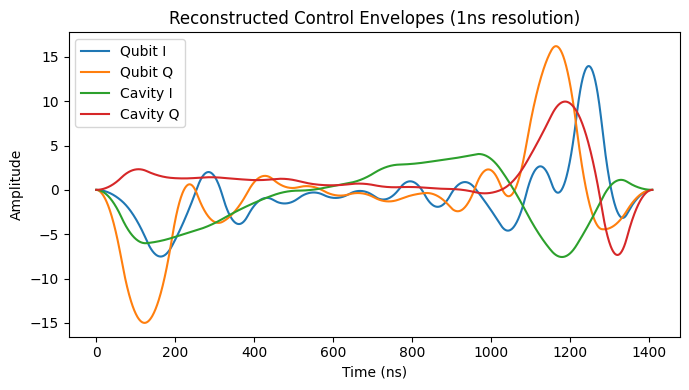

In [ ]:
import os
import glob
import numpy as np
import jax.numpy as jnp
import dynamiqs as dq
import qutip as qt
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
from qutip import wigner
from IPython.display import HTML
from matplotlib import animation
from matplotlib.patches import Circle


data = np.load(bundle_path)
print(f"Loaded optimization bundle from: {bundle_path}")

coeffs = data['coeffs_raw']*20.0
T_ns_hw = int(data['T_ns'])
T_us_hw = float(data['T_us'])

# --- Reconstruct on a fine 1ns grid for Dynamiqs ---
# Dynamiqs PWC requires N edges and N-1 amplitudes (midpoints)
time_intervals_num = T_ns_hw 
t_edges_us = np.linspace(0, T_us_hw, time_intervals_num + 1)
t_mids_us  = (t_edges_us[1:] + t_edges_us[:-1]) / 2
delta_ts = t_edges_us[1:] - t_edges_us[:-1]

# Rebuild the builder using saved metadata
bspline_builder = setup_bspline_builder(
    time_start=0.0, 
    time_end=T_us_hw, 
    n=int(data['n']), 
    k=int(data['k']), 
    skip_left=int(data['skip_left']), 
    skip_right=int(data['skip_right'])
)

bsplns_mids = bspline_builder(t_mids_us)
fields_mids = coeffs @ bsplns_mids  # Shape: (4, time_intervals_num)

eps_qubit_I = fields_mids[0]
eps_qubit_Q = fields_mids[1]
eps_cav_I   = fields_mids[2]
eps_cav_Q   = fields_mids[3]

plt.figure(figsize=(7,4))
plt.plot(t_mids_us * 1e3, eps_qubit_I, label="Qubit I")
plt.plot(t_mids_us * 1e3, eps_qubit_Q, label="Qubit Q")
plt.plot(t_mids_us * 1e3, eps_cav_I, label="Cavity I")
plt.plot(t_mids_us * 1e3, eps_cav_Q, label="Cavity Q")
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude")
plt.title("Reconstructed Control Envelopes (1ns resolution)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
N_cav_dq = 40
N_lev_dq = 3

# Operators
Iq = dq.eye(N_lev_dq)
Ic = dq.eye(N_cav_dq)
a_q = dq.tensor(dq.destroy(N_lev_dq), Ic)
a_c = dq.tensor(Iq, dq.destroy(N_cav_dq))
a_q_dag = dq.dag(a_q)
a_c_dag = dq.dag(a_c)
n_q = a_q_dag @ a_q
n_phot = a_c_dag @ a_c

# Drift Hamiltonian
chi_mhz = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
aham_mhz = 2 * jnp.pi * cfg["anharmonicity_MHz"]
cavity_self_kerr = 2*jnp.pi*cfg["self_Kerr_kHz"]*1e-3  # cavity self-Kerr MHz

H0 = chi_mhz * n_phot @ n_q + (aham_mhz / 2) * a_q_dag @ a_q_dag @ a_q @ a_q + 0.5 * cavity_self_kerr * (a_c_dag @ a_c_dag @ a_c @ a_c)

# Control Hamiltonians (Matches the I+iQ derivation)
H_ctrl_qub_I = a_q + a_q_dag
H_ctrl_qub_Q = -1j * (a_q_dag - a_q)
H_ctrl_cav_I = a_c + a_c_dag
H_ctrl_cav_Q = -1j * (a_c_dag - a_c)

# Dissipation Rates (Units: MHz)
kappa_s = 1 / cfg["storage_T1_us"] 
kappa_t1 = 1 / cfg["qubit_T1_us"] 
kappa_t2 = 1 / cfg["qubit_T2_us"] 
kappa_phi = -kappa_t1 / 2 + kappa_t2

n_th_cav = cfg["storage_thermal_population"]
n_th_qubit = cfg["qubit_thermal_population"]

rate_down_cav = kappa_s * (1 - n_th_cav)
rate_up_cav = kappa_s * n_th_cav
rate_down_qubit = kappa_t1 * (1 - n_th_qubit)
rate_up_qubit = kappa_t1 * n_th_qubit
rate_phase = kappa_phi

# Jump Operators
l_down_cav = jnp.sqrt(rate_down_cav) * a_c
l_up_cav = jnp.sqrt(rate_up_cav) * a_c_dag
l_down_qubit = jnp.sqrt(rate_down_qubit) * a_q
l_up_qubit = jnp.sqrt(rate_up_qubit) * a_q_dag
l_phase = jnp.sqrt(2 * rate_phase) * n_q

jump_ops = [l_down_cav, l_up_cav, l_down_qubit, l_up_qubit, l_phase]

In [ ]:
# Initial and Target States
psi_init_dq = dq.tensor(dq.basis(N_lev_dq, 0), dq.basis(N_cav_dq, 0))
rho0 = dq.todm(psi_init_dq)




psi_target_cav_dq = dq.coherent(N_cav_dq, 2.0)-dq.coherent(N_cav_dq, -2.0)
# psi_target_cav_dq =dq.basis(N_cav_dq,2)
psi_target_cav_dq = psi_target_cav_dq/dq.norm(psi_target_cav_dq)

psi_target_dq = dq.tensor(dq.basis(N_lev_dq, 0),psi_target_cav_dq)
rho_target = dq.todm(psi_target_dq)

# Construct Time-Dependent Hamiltonian
t_edges = jnp.asarray(t_edges_us)
eps_qub_I_jnp = jnp.asarray(eps_qubit_I)
eps_qub_Q_jnp = jnp.asarray(eps_qubit_Q)
eps_cav_I_jnp = jnp.asarray(eps_cav_I)
eps_cav_Q_jnp = jnp.asarray(eps_cav_Q)

H_qub_I_t = dq.pwc(t_edges, eps_qub_I_jnp, H_ctrl_qub_I)
H_qub_Q_t = dq.pwc(t_edges, eps_qub_Q_jnp, H_ctrl_qub_Q)
H_cav_I_t = dq.pwc(t_edges, eps_cav_I_jnp, H_ctrl_cav_I)
H_cav_Q_t = dq.pwc(t_edges, eps_cav_Q_jnp, H_ctrl_cav_Q)

H_t = H0 + H_qub_I_t + H_qub_Q_t + H_cav_I_t + H_cav_Q_t

# Integration settings
tsave = t_edges # Save at every 1 ns edge
method = dq.method.Tsit5(rtol=1e-8, atol=1e-10, max_steps=1_000_000)
opts   = dq.Options(save_states=True, progress_meter=True)

# Solve
result_dq = dq.mesolve(
    H=H_t,
    jump_ops=jump_ops,
    rho0=rho0,
    tsave=tsave,
    exp_ops=[n_phot, n_q], 
    method=method,
    options=opts,
)

rho_final = result_dq.states[-1]
F_final = float(dq.fidelity(rho_final, rho_target))
print(f"Fidelity (mesolve, with decoherence): {F_final:.8f}")

|██████████| 100.0% ◆ elapsed 8.12s ◆ remaining 0.00ms  


Fidelity (mesolve, with decoherence): 0.95298862
